# Land Use Classification Cleaning

This notebook demonstrates cleaning two land-use rasters using `multiclean.clean_array`.

We load two inputs, apply edge smoothing and small-island removal, and visualize simple before/after results.

## Setup

- `clean_array`: Performs morphological opening (edge smoothing), removes small connected components (islands), and fills gaps using nearest valid class.
- Parameters to tune:
  - `smooth_edge_size` (pixels): Opening kernel size; higher smooths more.
  - `min_island_size` (pixels): Remove components with area less than this threshold.
  - `connectivity`: 4 or 8 for connected component analysis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio as rio
from multiclean import clean_array

## Paths

Set the data directory and file paths (provided under `notebooks/data/`).

In [2]:
data_dir = Path().cwd() / "data"
land_use_sample_a_path = data_dir / "land use a.tif"
land_use_sample_b_path = data_dir / "land use b.tif"
print("A:", land_use_sample_a_path)
print("B:", land_use_sample_b_path)


A: /home/nick/Documents/MultiClean/notebooks/data/land use a.tif
B: /home/nick/Documents/MultiClean/notebooks/data/land use b.tif


## Load rasters

Each raster is a single-band integer class label image.

In [ ]:
array_a = rio.open(land_use_sample_a_path).read(1)
array_b = rio.open(land_use_sample_b_path).read(1)
print("A unique classes:", np.unique(array_a)[:10])
print("B unique classes:", np.unique(array_b)[:10])


A unique classes: [  0. 113. 114. 117. 120. 130. 132. 133. 210. 220.]
B unique classes: [113 115 116 117 120 130 133 210 220 320]


## Clean both rasters

We use slightly different parameters for A and B to reflect different noise levels. Adjust as needed for your data.

In [5]:
array_a_cleaned = clean_array(
    array=array_a, smooth_edge_size=1, min_island_size=5, connectivity=8
)
array_b_cleaned = clean_array(
    array=array_b, smooth_edge_size=3, min_island_size=10, connectivity=8
)


## Visualize

Side-by-side original and cleaned for both A and B. Using `nearest` interpolation for crisp class labels.

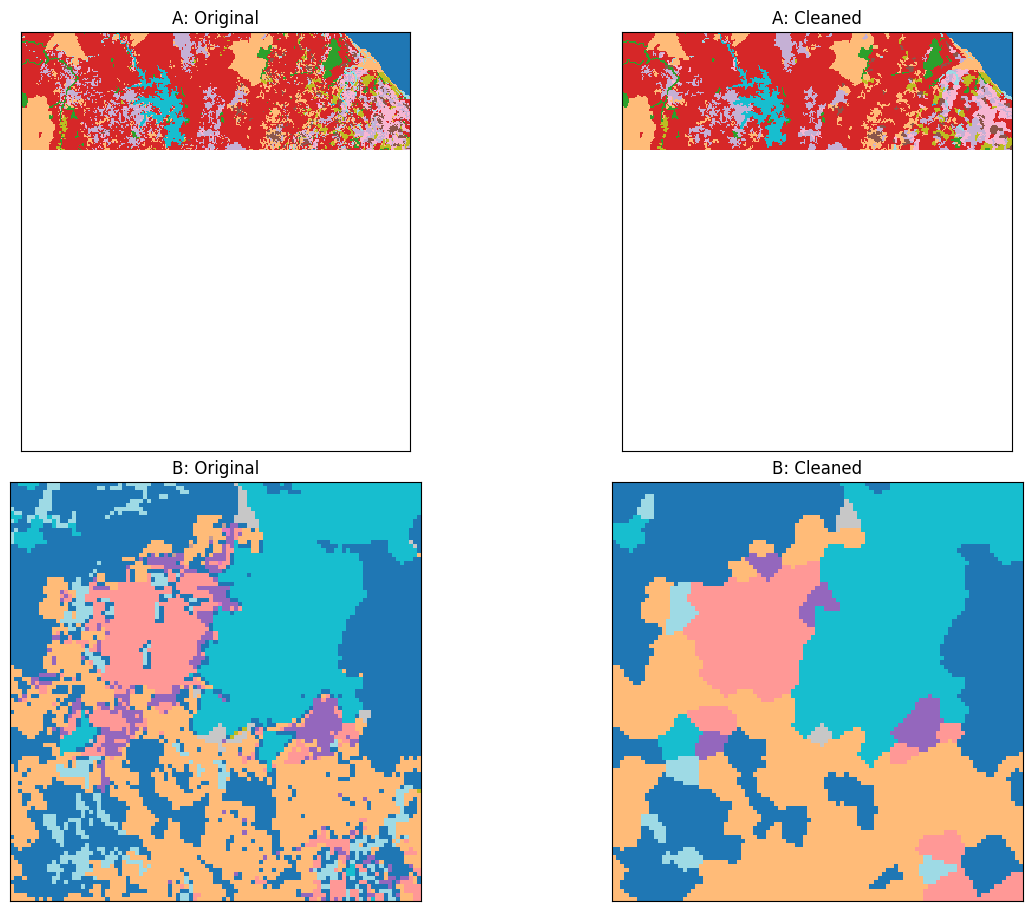

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
cmap = plt.get_cmap("tab20")
axes[0, 0].imshow(array_a, cmap=cmap, interpolation="nearest")
axes[0, 0].set_title("A: Original")
axes[0, 1].imshow(array_a_cleaned, cmap=cmap, interpolation="nearest")
axes[0, 1].set_title("A: Cleaned")
axes[1, 0].imshow(array_b, cmap=cmap, interpolation="nearest")
axes[1, 0].set_title("B: Original")
axes[1, 1].imshow(array_b_cleaned, cmap=cmap, interpolation="nearest")
axes[1, 1].set_title("B: Cleaned")
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()
